## **Leyendo los archivos, limpiandolos y uniendodolos.**

In [15]:
import pandas as pd
import os

# Cargar Datasets
DATA_PATH = os.path.join('..', 'data', '01_raw')

CLIMA_FILE = os.path.join(DATA_PATH, 'clima_cali_openmeteo.csv')
DANE_FILE = os.path.join(DATA_PATH, 'DCD-area-proypoblacion-Mun-2020-2035-ActPostCOVID-19.xlsx')
SIVIGILA_FILE = os.path.join(DATA_PATH, 'sivigila_historico_cali.csv')

df_clima = pd.read_csv(CLIMA_FILE)
df_poblacion = pd.read_excel(DANE_FILE, sheet_name=0, header=8)
df_sivigila_historico = pd.read_csv( SIVIGILA_FILE, sep=',')

### **Inspección Inicial**

In [16]:
print('Dataset de Clima (API Open-Meteo)')
df_clima.info()
df_clima.head()

Dataset de Clima (API Open-Meteo)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3608 entries, 0 to 3607
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   fecha            3608 non-null   object 
 1   temp_media_c     3608 non-null   float64
 2   precip_total_mm  3608 non-null   float64
dtypes: float64(2), object(1)
memory usage: 84.7+ KB


,fecha,temp_media_c,precip_total_mm
0,2016-01-01,22.7,0.7
1,2016-01-02,22.4,2.0
2,2016-01-03,21.3,7.6
3,2016-01-04,21.4,3.8
4,2016-01-05,21.9,7.3


In [17]:
print('Dataset de Población (DANE)')
df_poblacion.info()
df_poblacion.head()

Dataset de Población (DANE)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53859 entries, 0 to 53858
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DP               53859 non-null  object 
 1   DPNOM            53856 non-null  object 
 2   MPIO             53856 non-null  float64
 3   DPMP             53856 non-null  object 
 4   AÑO              53856 non-null  float64
 5   ÁREA GEOGRÁFICA  53856 non-null  object 
 6   Población        53856 non-null  float64
dtypes: float64(3), object(4)
memory usage: 2.9+ MB


,DP,DPNOM,MPIO,DPMP,AÑO,ÁREA GEOGRÁFICA,Población
0,05,Antioquia,5001.0,Medellín,2020.0,Cabecera Municipal,2476569.0
1,05,Antioquia,5001.0,Medellín,2020.0,Centros Poblados y Rural Disperso,43023.0
2,05,Antioquia,5001.0,Medellín,2020.0,Total,2519592.0
3,05,Antioquia,5001.0,Medellín,2021.0,Cabecera Municipal,2506656.0
4,05,Antioquia,5001.0,Medellín,2021.0,Centros Poblados y Rural Disperso,42352.0


In [18]:
print('Dataset de Casos de Dengue (SIVIGILA)')
df_sivigila_historico.info()
df_sivigila_historico.head()

Dataset de Casos de Dengue (SIVIGILA)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   ano           365 non-null    int64
 1   semana        365 non-null    int64
 2   casos_dengue  365 non-null    int64
dtypes: int64(3)
memory usage: 8.7 KB


,ano,semana,casos_dengue
0,2018,2,31
1,2020,2,390
2,2017,3,198
3,2018,3,31
4,2019,3,32


## **Transformación de datos**

haciendo ajustes antes del merge

### **Población**

In [19]:
import numpy as np

print("\n[DANE] Limpiando nombres de columnas...")
nuevos_nombres_dane = [
    'dp', 'dpnom', 'mpio', 'dpmp', 
    'año', 'area_geografica', 'poblacion'
]
df_poblacion.columns = nuevos_nombres_dane
print(f"Nuevas columnas DANE: {df_poblacion.columns.to_list()}")

# Extraer la población de Cali para 2024
print("Extrayendo población de Cali para 2024...")
try:
    df_poblacion.dropna(subset=['año'], inplace=True)
    
    # Convertimos 'año' a entero para una comparación segura
    df_poblacion['año'] = df_poblacion['año'].astype(float).astype(int)
    
    pob_cali_df = df_poblacion[
        (df_poblacion['dpmp'].astype(str).str.upper() == 'CALI') &
        (df_poblacion['area_geografica'].astype(str).str.upper() == 'TOTAL') &
        (df_poblacion['año'] == 2024)
    ]
    
    poblacion_cali = int(pob_cali_df['poblacion'].iloc[0])
    print(f"Población de Cali (2024): {poblacion_cali:,}")
    
except Exception as e:
    print(f"Error al extraer población: {e}.")


[DANE] Limpiando nombres de columnas...
Nuevas columnas DANE: ['dp', 'dpnom', 'mpio', 'dpmp', 'año', 'area_geografica', 'poblacion']
Extrayendo población de Cali para 2024...
Población de Cali (2024): 2,283,846


### **Clima (Promedios Semanales)**

In [20]:
# Transformar Clima (Diario a Semanal)
print("\n[Clima] Transformando datos diarios a semanales...")

df_clima['fecha'] = pd.to_datetime(df_clima['fecha'])

# Establecer la fecha como índice para poder 'remuestrear' (resample)
df_clima.set_index('fecha', inplace=True)

# Remuestrear: agrupar por semana ('W-MON' = semanas que empiezan el Lunes)
df_clima_semanal = df_clima.resample('W-MON').agg(
    temp_media_semanal= ('temp_media_c', 'mean'), 
    precip_total_semanal=('precip_total_mm', 'sum')
).copy()


[Clima] Transformando datos diarios a semanales...


In [21]:
print("Datos climáticos agregados por semana:")
df_clima_semanal.head()

Datos climáticos agregados por semana:


,temp_media_semanal,precip_total_semanal
fecha,,
2016-01-04,21.950000,14.1
2016-01-11,21.514286,122.3
2016-01-18,21.414286,20.5
2016-01-25,21.685714,55.7
2016-02-01,21.214286,39.5


### **Casos Dengue Semanales**

In [22]:
# Transformar SIVIGILA (Datos Agregados a Serie de Tiempo)
print("\n[SIVIGILA] Transformando datos históricos de Dengue en Cali...")
try:
    # Asegurarnos de que los tipos de datos sean correctos
    df_sivigila_historico['ano'] = df_sivigila_historico['ano'].astype(str)
    df_sivigila_historico['semana'] = df_sivigila_historico['semana'].astype(str)
    df_sivigila_historico['casos_dengue'] = pd.to_numeric(df_sivigila_historico['casos_dengue'])

    # Crear la columna de fecha unificada
    # Usamos %G (Año ISO) y %V (Semana ISO), asumiendo que la semana empieza el lunes (%u=1)
    df_sivigila_historico['fecha_str'] = df_sivigila_historico['ano'] + '-' + \
                                         df_sivigila_historico['semana'] + '-1'
    
    df_sivigila_historico['fecha'] = pd.to_datetime(
        df_sivigila_historico['fecha_str'], 
        format='%G-%V-%u' # Formato para Año-Semana ISO-Día de la semana
    )

    # Establecer la fecha como índice y seleccionar la columna de casos
    df_casos_semanal = df_sivigila_historico.set_index('fecha')[['casos_dengue']].sort_index()
    
    print("Casos de dengue listos como serie de tiempo")

except Exception as e:
    print(f"Ocurrió un error procesando SIVIGILA: {e}")



[SIVIGILA] Transformando datos históricos de Dengue en Cali...
Casos de dengue listos como serie de tiempo


In [23]:
df_casos_semanal.head()

,casos_dengue
fecha,
2016-01-04,401
2016-01-11,475
2016-01-18,533
2016-01-25,628
2016-02-01,734


### **Unír y crear Dataset Maestro**

In [24]:
print("Uniendo df_casos_semanal y df_clima_semanal")
df_master = df_casos_semanal.join(df_clima_semanal, how='inner')

print(f"Semanas con casos: {len(df_casos_semanal)}")
print(f"Semanas con clima: {len(df_clima_semanal)}")
print(f"Semanas en df_master (intersección): {len(df_master)}")

# Añadir Población como una columna constante y Calcular Tasa
df_master['poblacion'] = poblacion_cali
    
# Crear nuestra variable objetivo, Tasa de Incidencia por 100,000 hab.
df_master['tasa_incidencia_100k'] = (df_master['casos_dengue'] / df_master['poblacion']) * 100000

# Limpiar NaNs (si el 'mean' o 'sum' del clima falló en alguna semana)
df_master.dropna(inplace=True)

print(f"Semanas finales (sin NaNs): {len(df_master)}")
    
# Guardar nuestro Dataset
# Usamos Parquet porque guarda los tipos de datos.
PROCESSED_DATA_PATH = os.path.join('..', 'data', '03_processed')
os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)
MASTER_FILE = os.path.join(PROCESSED_DATA_PATH, 'master_dataset_cali.parquet')
    
print(f"\nDataset Maestro Guardado en: {MASTER_FILE}")
df_master.to_parquet(MASTER_FILE)


Uniendo df_casos_semanal y df_clima_semanal
Semanas con casos: 365
Semanas con clima: 516
Semanas en df_master (intersección): 365
Semanas finales (sin NaNs): 365

Dataset Maestro Guardado en: ../data/03_processed/master_dataset_cali.parquet


In [25]:
df_master.info()
df_master.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 365 entries, 2016-01-04 to 2022-12-26
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   casos_dengue          365 non-null    int64  
 1   temp_media_semanal    365 non-null    float64
 2   precip_total_semanal  365 non-null    float64
 3   poblacion             365 non-null    int64  
 4   tasa_incidencia_100k  365 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 17.1 KB


,casos_dengue,temp_media_semanal,precip_total_semanal,poblacion,tasa_incidencia_100k
fecha,,,,,
2016-01-04,401,21.950000,14.1,2283846,17.558102
2016-01-11,475,21.514286,122.3,2283846,20.798250
2016-01-18,533,21.414286,20.5,2283846,23.337826
2016-01-25,628,21.685714,55.7,2283846,27.497476
2016-02-01,734,21.214286,39.5,2283846,32.138769


### **Dataset Maestro creado.**

## **EDA**

In [26]:
# Librerías
import matplotlib.pyplot as plt
import seaborn as sns       

In [27]:
PROCESSED_DATA_PATH = os.path.join('..', 'data', '03_processed')
MASTER_FILE = os.path.join(PROCESSED_DATA_PATH, 'master_dataset_cali.parquet')

df_master = pd.read_parquet(MASTER_FILE)
df_master.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 365 entries, 2016-01-04 to 2022-12-26
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   casos_dengue          365 non-null    int64  
 1   temp_media_semanal    365 non-null    float64
 2   precip_total_semanal  365 non-null    float64
 3   poblacion             365 non-null    int64  
 4   tasa_incidencia_100k  365 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 17.1 KB


### **Serie de tiempo de casos de Dengue**
- ¿Cómo se han comportado los casos de Dengue a lo largo del tiempo?

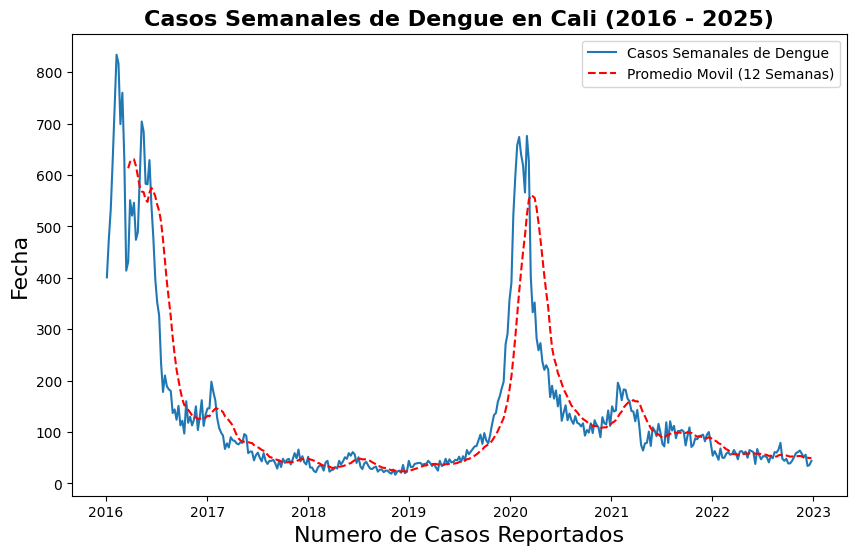

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(
    df_master.index,
    df_master['casos_dengue'],
    label='Casos Semanales de Dengue'
)

# Añadir un Promedio Móvil - 'window=12' = un promedio móvil de 12 semanas (aprox. 3 meses)
# Esto suaviza la línea y nos permite ver la "tendencia" subyacente
df_master['casos_promedio_movil_12sem'] = df_master['casos_dengue'].rolling(window=12).mean()

plt.plot(
    df_master.index,
    df_master['casos_promedio_movil_12sem'],
    color='red',
    linestyle='--',
    label='Promedio Movil (12 Semanas)'
)

plt.title('Casos Semanales de Dengue en Cali (2016 - 2025)', fontsize=16, fontweight='bold')
plt.ylabel('Fecha', fontsize=16)
plt.xlabel('Numero de Casos Reportados', fontsize=16)
plt.legend()
plt.show()

**Conclusión**

**El Dengue es Cíclico: No es un problema constante. Funciona en "oleadas". Vemos claramente los "picos" (brotes epidémicos) y los "valles" (períodos inter-epidémicos).**

- Vemos un pico masivo en 2016.

- Vemos un período de calma en 2017-2018.

- Vemos la epidemia más grande de todas en 2019-2020.

### **¿Qué causa esos picos?**

Nuestra hipótesis es el clima. El ciclo de vida del mosquito depende de la lluvia y la temperatura.

Pero no es una relación instantánea. La lluvia de esta semana no causa el pico de dengue de esta semana. Causa el pico de dengue de 4 semanas en el futuro (charcos -> larvas -> mosquitos -> picaduras -> hospital).

**El mosquito (Aedes aegypti) tiene un ciclo de vida que depende del clima pasado:**

* La lluvia de hoy no crea un caso de dengue mañana.
* La lluvia de hoy crea charcos.
* Esos charcos crían larvas durante 1-2 semanas.
* El mosquito adulto emerge, se infecta y pica a un humano (1-2 semanas más).
* El humano se enferma y va al hospital (1 semana después).

**El "retraso" (lag) total es de 2 a 4 semanas**

### Continuamos el **EDA** en el siguiente Notebook (03_EDA_df_Master.ipynb)

---